# Pre-processing

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
from copy import deepcopy # for copying objects
import random
random.seed(42) # ensures reproductibility

In [2]:
# Data import and initial exploration
pharma_sales_data = pd.read_csv(r'C:\Users\hugo9\python course\salesmonthly.csv')
pharma_sales_data.head()

# Data is sorted by year and month. Data recollection is done the last day of each month

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-31,127.69,99.090,152.100,878.030,354.0,50.0,112.0,48.2
1,2014-02-28,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2
2,2014-03-31,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4
3,2014-04-30,113.10,89.475,130.900,698.500,209.0,18.0,97.0,73.7
4,2014-05-31,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7


In [3]:
# Data types
pharma_sales_data.dtypes
# Date is an object type. Its needed to convert it to a datetime64 data type.
pharma_sales_data['datum'] = pd.to_datetime(pharma_sales_data['datum'], format='%Y-%m-%d')

In [4]:
# Overall info
pharma_sales_data.info()
# 70 observations, 9 predictors, no null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   datum   70 non-null     datetime64[ns]
 1   M01AB   70 non-null     float64       
 2   M01AE   70 non-null     float64       
 3   N02BA   70 non-null     float64       
 4   N02BE   70 non-null     float64       
 5   N05B    70 non-null     float64       
 6   N05C    70 non-null     float64       
 7   R03     70 non-null     float64       
 8   R06     70 non-null     float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 5.1 KB


In [5]:
pharma_sales_data.tail()
# Seems like data from last months of 2019 is missing, according to the information given by the data provider

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
65,2019-06-30,151.54,101.627,103.20,610.00,193.0,25.0,142.0,156.04
66,2019-07-31,181.00,103.541,92.80,649.80,250.6,20.0,115.0,105.20
67,2019-08-31,181.91,88.269,84.20,518.10,237.0,26.0,145.0,97.30
68,2019-09-30,161.07,111.437,93.50,984.48,227.8,16.0,161.0,109.10
69,2019-10-31,44.37,37.300,20.65,295.15,86.0,7.0,37.0,11.13


In [6]:
# Imputing missing data
# First we analyze the statistical features of the series.
df1 = deepcopy(pharma_sales_data) # Copy of the data frame
from statsmodels.tsa.stattools import adfuller # Augmented Dickey-Fuller test for stationarity

for column in df1.columns[1:]:
    data = df1[column]

    # ADF Test
    adfTuple = adfuller(data)
    # print(f'Column: {column}')
    # print('ADF Statistic:', adfTuple[0])
    # print('p-value:', adfTuple[1])
    # print('Critical Values:', adfTuple[4])
    # print('\n')

# According to the p-value, our columns 'M01AB', 'M01AE', 'N02BE', 'N05B', 'N05C', 'R03' are
# stationary time series, whereas 'N02BA' and 'R06' are non-stationary time series.

In [7]:
# Imputing considering the median
newRows = pd.DataFrame({'datum': pd.to_datetime(['2019-11-30', '2019-12-31'])})
df1 = pd.concat([df1, newRows], ignore_index=True) # Adding november and december new datum lines

# Iteration for the imputation of median value of each drug category. Median is calculated with
# previous values to '2019-11-01'
for drug in df1.columns.difference(['datum']): # drug category list
    medianValue = df1.loc[df1['datum'] < '2019-11-01', drug].median()

    # Imputing new values
    df1.loc[df1['datum'] == '2019-11-30', drug] = medianValue
    df1.loc[df1['datum'] == '2019-12-31', drug] = medianValue

df1.tail(2) # Missing values are imputed

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
70,2019-11-30,154.635,114.84,117.225,865.8245,250.3,18.0,160.0,74.1
71,2019-12-31,154.635,114.84,117.225,865.8245,250.3,18.0,160.0,74.1


In [8]:
pharma_sales_data = deepcopy(df1) # updating the original df
# Now we are ready to start answering our questions

# Which classes of drugs saw an increase or decrease in demand between 2014 and 2019?

In [9]:
# Grouping by year and sum of the sales for each drug category.
df1['datum'] = df1['datum'].dt.year.astype('int64') # Stripping month and day data from our dates
df1 = df1.groupby('datum').sum() # Aggregation function
df1 # Sum of sales for each category data grouped by year


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
datum,,,,,,,,
2014,1510.77,1333.594,1683.279,10094.555,4355.0,303.0,1277.00,828.30
2015,1905.62,1496.603,1608.630,11997.350,2965.0,159.0,1776.25,983.03
2016,2125.06,1604.441,1664.800,13435.830,3278.5,207.0,2137.00,1065.07
2017,1653.79,1214.485,1091.150,7674.919,2078.0,142.0,1732.00,919.61
2018,1786.93,1389.656,1123.800,11263.675,3266.2,242.0,2765.00,1196.80
2019,1826.54,1346.901,1114.250,9743.265,2906.2,232.0,2370.00,1221.77


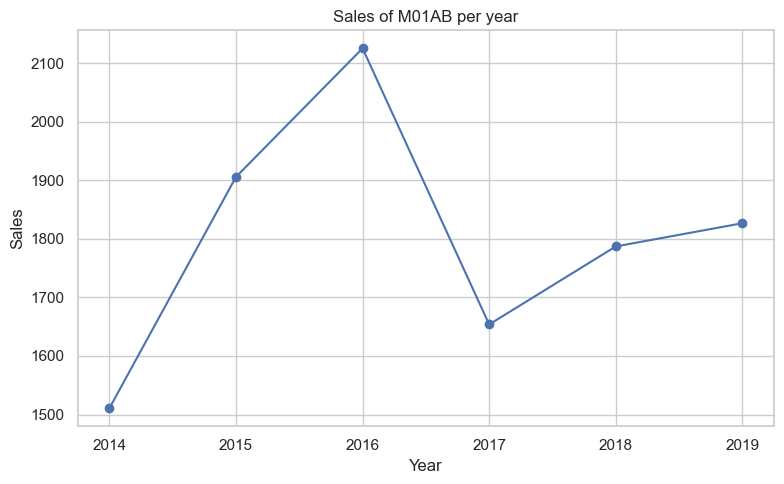

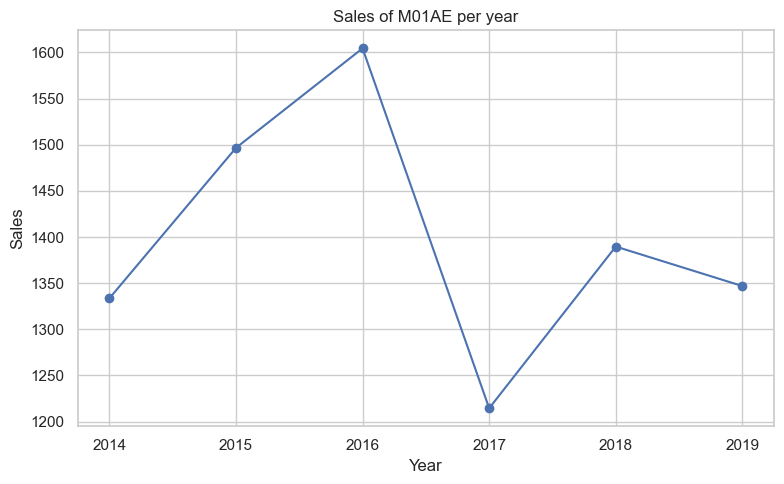

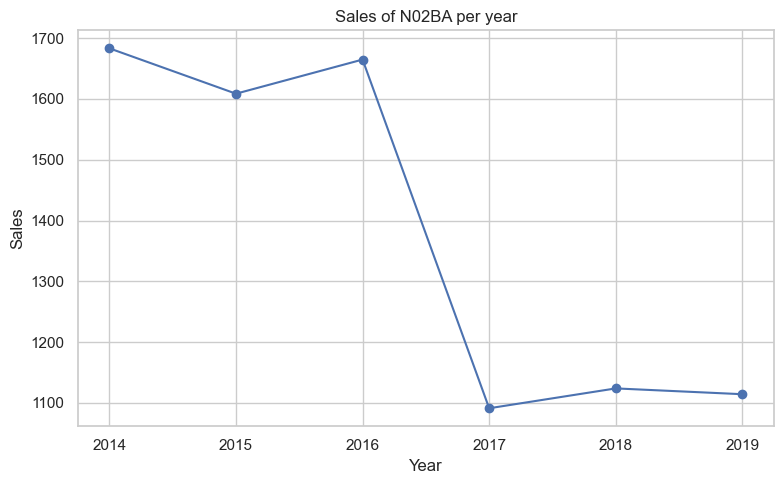

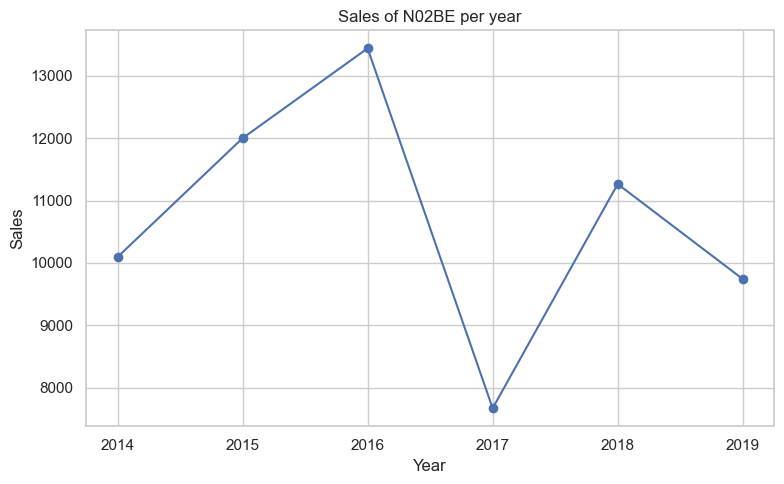

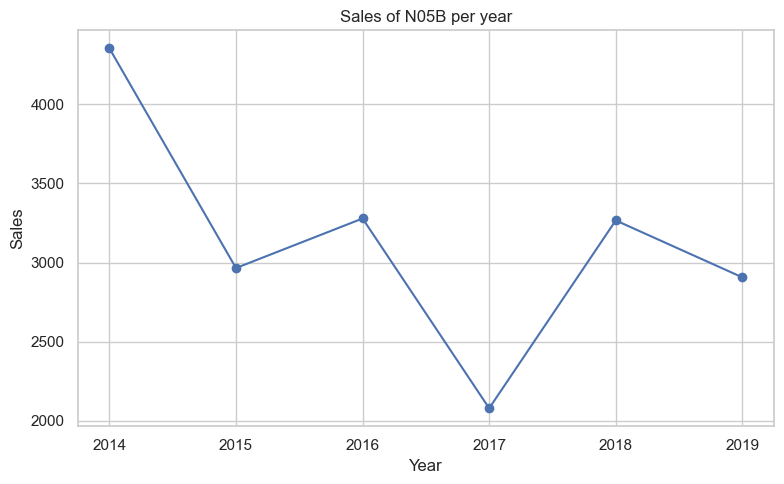

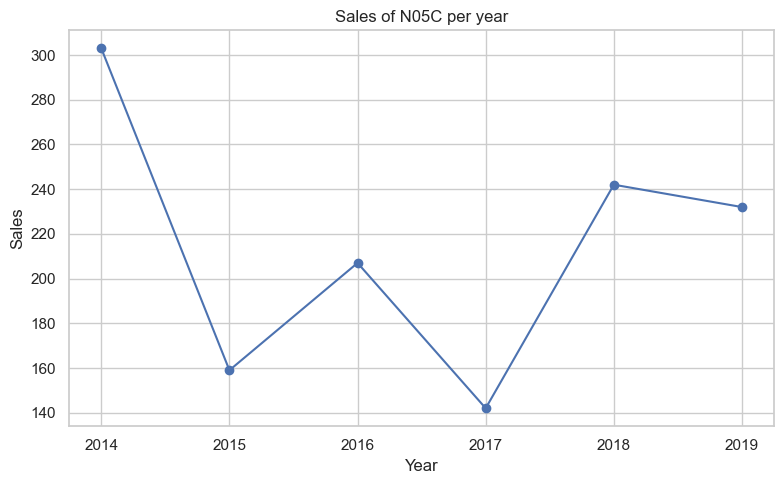

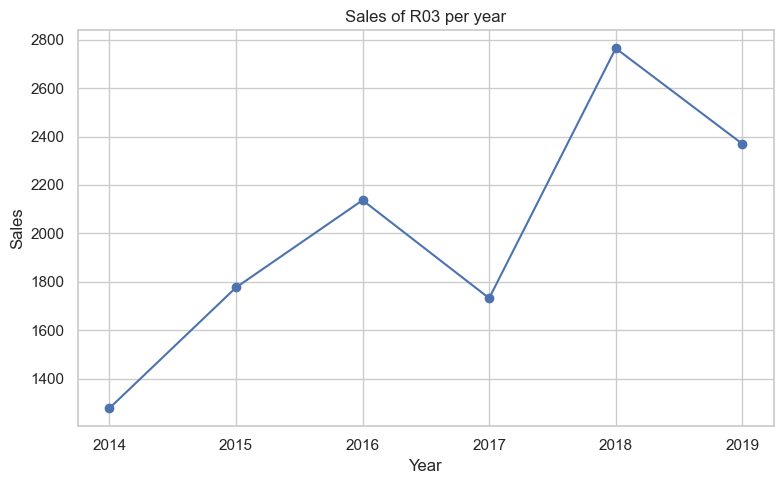

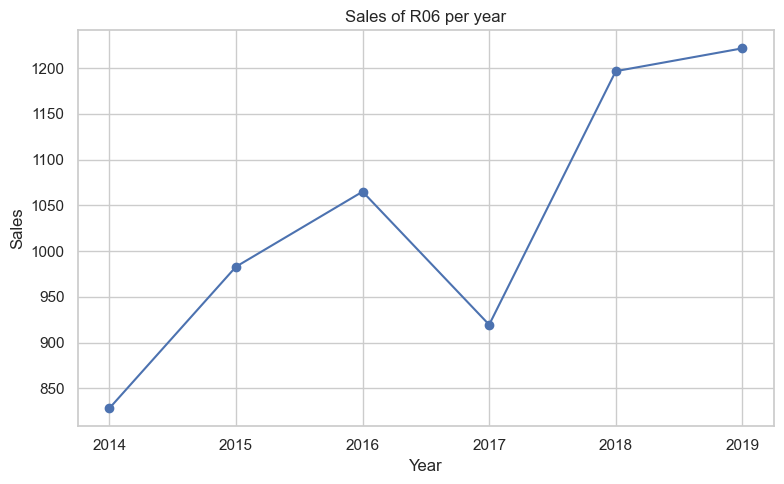

In [10]:
# Data Visualization
sns.set(style='whitegrid')
for drug in df1.columns:
    plt.figure(figsize=(8,5))
    plt.plot(df1.index, df1[drug], marker='o', linestyle='-', label=column)
    plt.xlabel('Year')
    plt.ylabel('Sales')
    plt.title(f'Sales of {drug} per year')
    plt.grid(True)
    plt.tight_layout()
    plt.show()   


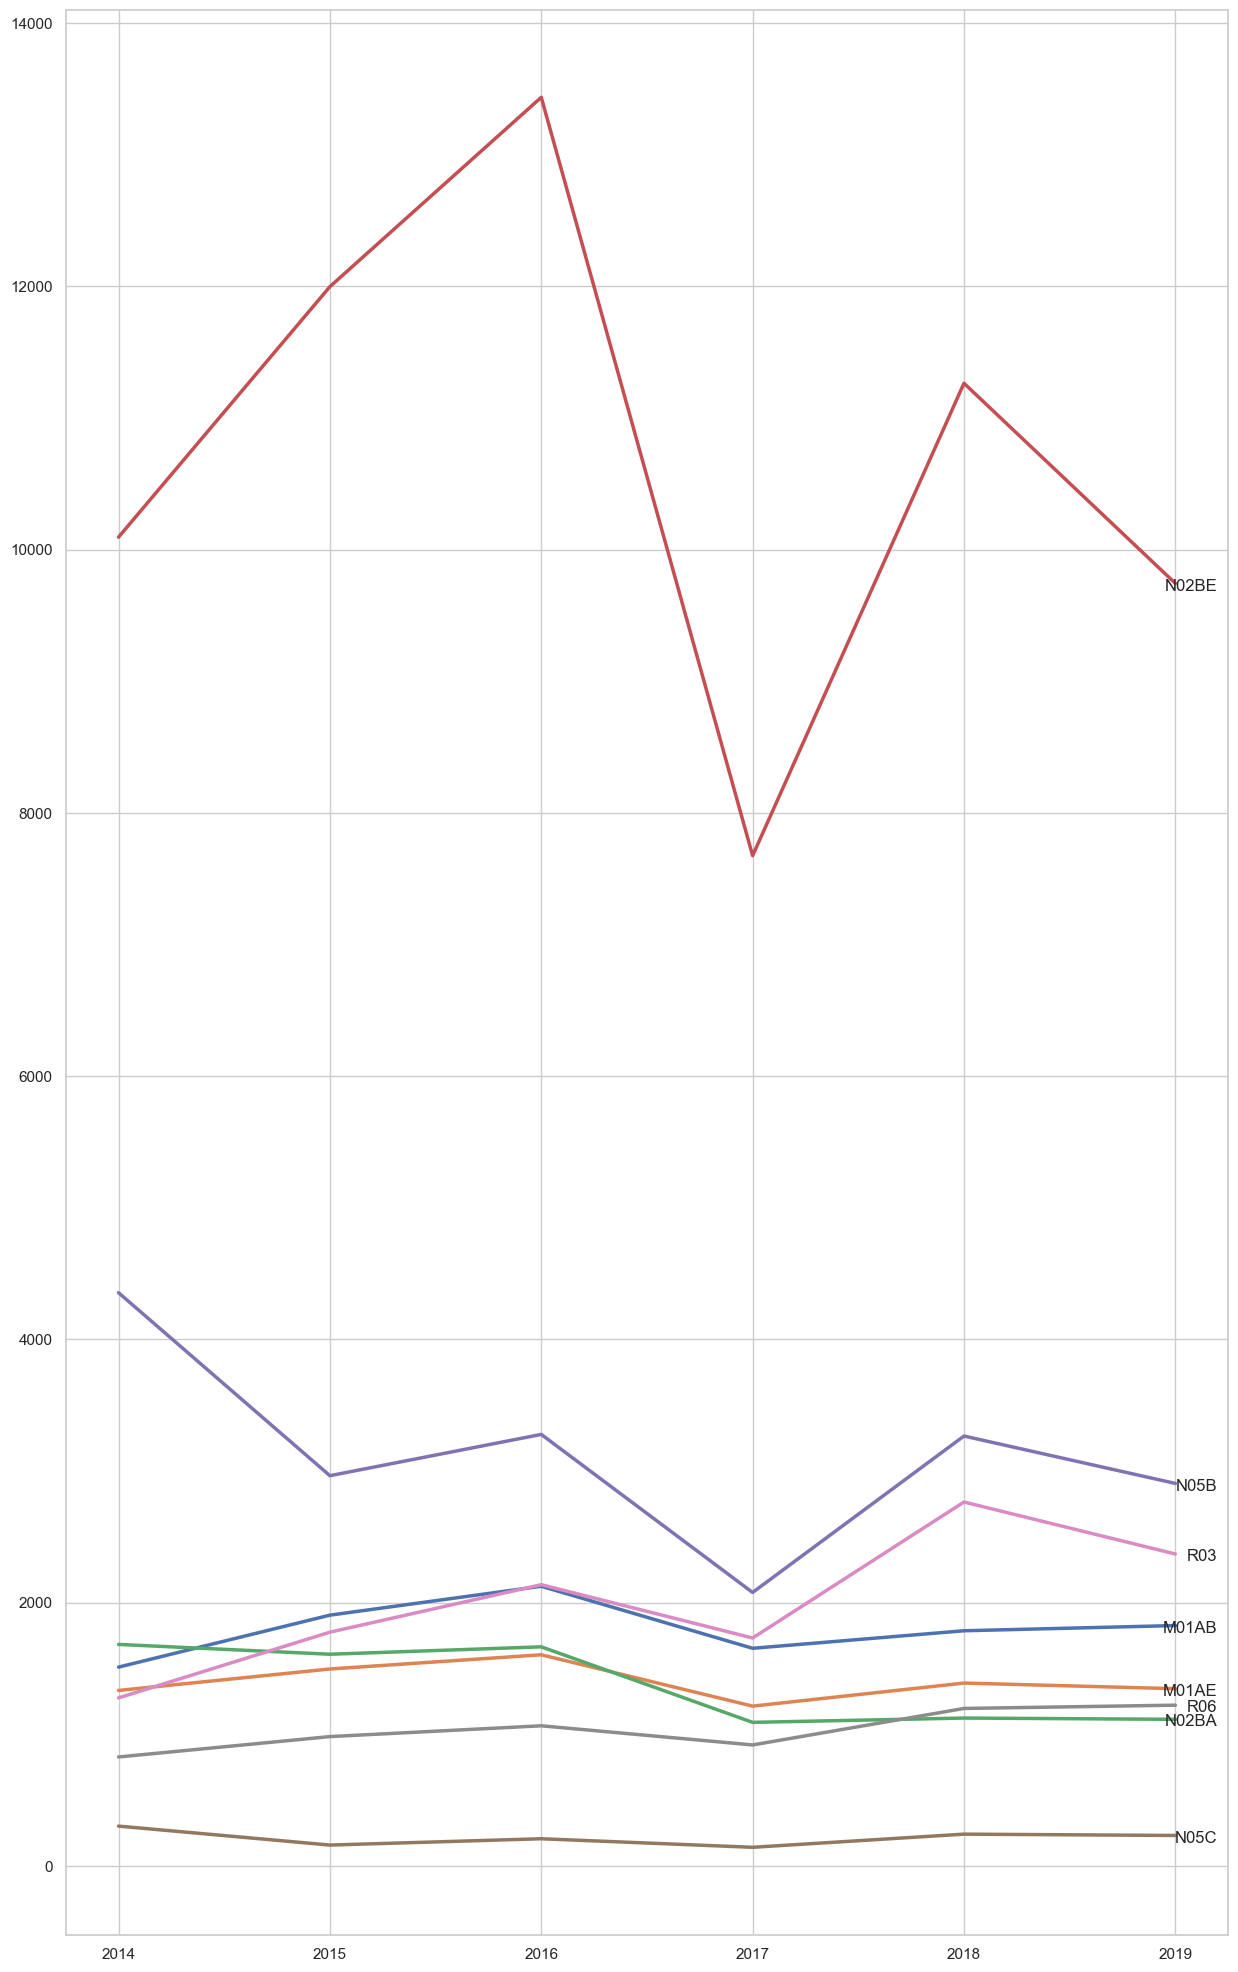

In [11]:
# Categories sum of sales as a function of time
plt.figure(figsize=(15,25))
for drug in df1.columns:
    plt.plot(df1[drug], label='_nolegend_', linewidth=2.5)
    xValue=df1.index
    yValue=df1[drug]
    xPos=xValue[-1]
    yPos=yValue.iloc[-1]
    plt.annotate(drug, xy=(xPos, yPos), xytext=(30,-5), textcoords='offset points', ha='right', 
                fontsize=12)
plt.show()

In [12]:
# Data from our beginning (2014) and our ending (2019)
df1a = df1.loc[(df1.index==2014) | (df1.index==2019)]
df1a.head()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
datum,,,,,,,,
2014,1510.77,1333.594,1683.279,10094.555,4355.0,303.0,1277.0,828.30
2019,1826.54,1346.901,1114.250,9743.265,2906.2,232.0,2370.0,1221.77


In [13]:
# Calculating the sales percentual changes for each category
percentage_rows = []

for drug in df1a.columns:
    start = df1a.loc[2014, drug]
    end = df1a.loc[2019, drug]
    percentage_change = ((end-start)/start)*100
    percentage_rows.append({'Class': drug, 'Percentage Change': percentage_change})

delta_df = pd.DataFrame(percentage_rows)



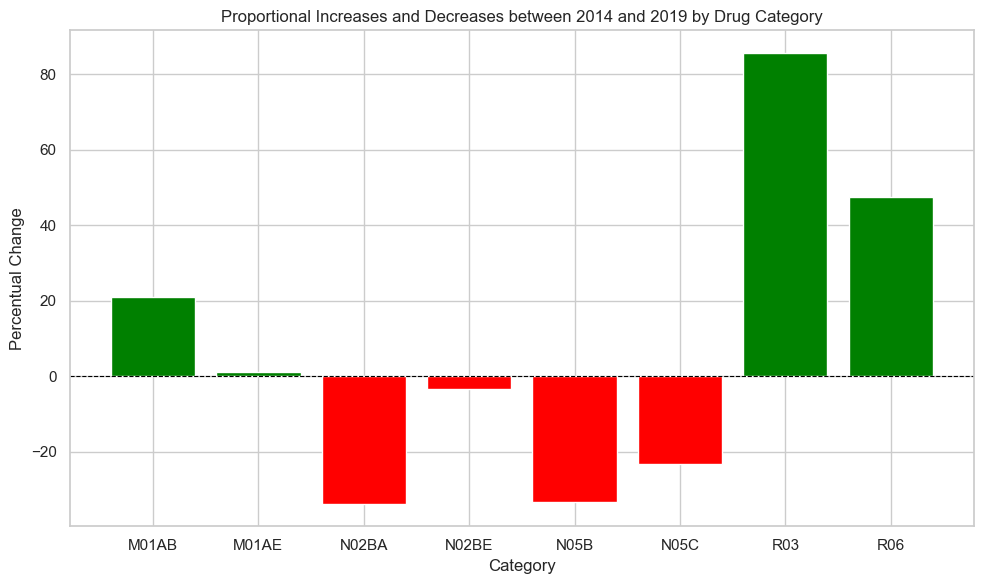

In [14]:
# Visualization of the percentage change (increases or decreases in sales)
plt.figure(figsize=(10,6))
plt.bar(delta_df['Class'], delta_df['Percentage Change'], color=['green' if x >= 0 else 'red' for x
       in delta_df['Percentage Change']])
plt.xlabel('Category')
plt.ylabel('Percentual Change')
plt.title('Proportional Increases and Decreases between 2014 and 2019 by Drug Category')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [15]:
# Four drugs categories showed an increase in sales between 2014 and 2019. 
    # Obstructive airway diseases (R03) showed an increase of about 85%
    # Systemic antihistamines (R06) showed an increase of about 45%
    # Nonsteroidal anti-inflammatory and antirheumatic drugs, acetic acid derivatives, and related substances (M01AB) showed an increase of about 20%.
    # Category M01AE showed an increase of about 1%

# Additional insights based on the data visualization
    # Medicines in category M01AB saw a sharp growth in sales between 2014 and 2016, then sales started to decline.
    # Medicines in category N02BA have been declining since 2014, with a more pronounced decrease between 2016 and 2017.
    # Medicines in category RO3 grew significantly between 2014 and 2018.
        # Despite this, there was a sharp drop in sales between 2018 and 2019; This information adds to the decision-making based in the real changes of the trend of these sales.
    

# Which months have the highest and lowest sales?

In [16]:
# To answer this question we have to group the data, this time by month rather than by year

df2 = deepcopy(pharma_sales_data)
df2.loc[:,'month'] = df2.datum.dt.month # new column for month values
df2 = df2.groupby('month').mean() # Aggregation function
df2 = round(df2,2)
df2 = df2.drop('datum', axis=1)
df2

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
month,,,,,,,,
1,124.54,114.94,111.07,1032.26,265.03,22.00,178.04,39.58
2,137.44,127.63,127.48,993.83,248.40,15.17,195.17,46.73
3,152.28,123.14,123.81,927.92,256.23,19.33,204.17,98.72
4,153.54,107.70,112.32,776.82,239.90,15.50,184.50,141.12
5,150.23,113.14,115.19,714.66,235.30,18.83,163.33,155.09
6,141.44,107.04,115.95,624.25,242.50,17.67,130.50,133.11
7,164.58,117.02,107.98,610.26,257.27,14.83,91.67,104.12
8,169.95,112.36,107.79,654.82,281.67,19.00,96.17,83.38
9,150.15,119.10,102.89,960.86,277.22,15.67,138.67,77.20


In [17]:
# Also, let's check if there's any trends related to the pair of month and year.
df2y = deepcopy(pharma_sales_data)
df2y.loc[:,'year'] = df2y.datum.dt.year
df2y.loc[:,'month'] = df2y.datum.dt.month
df2y = df2y.drop('datum', axis=1) # datum is no longer needed
df2y


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,year,month
0,127.690,99.090,152.100,878.0300,354.0,50.0,112.0,48.20,2014,1
1,133.320,126.050,177.000,1001.9000,347.0,31.0,122.0,36.20,2014,2
2,137.440,92.950,147.655,779.2750,232.0,20.0,112.0,85.40,2014,3
3,113.100,89.475,130.900,698.5000,209.0,18.0,97.0,73.70,2014,4
4,101.790,119.933,132.100,628.7800,270.0,23.0,107.0,123.70,2014,5
...,...,...,...,...,...,...,...,...,...,...
67,181.910,88.269,84.200,518.1000,237.0,26.0,145.0,97.30,2019,8
68,161.070,111.437,93.500,984.4800,227.8,16.0,161.0,109.10,2019,9
69,44.370,37.300,20.650,295.1500,86.0,7.0,37.0,11.13,2019,10
70,154.635,114.840,117.225,865.8245,250.3,18.0,160.0,74.10,2019,11


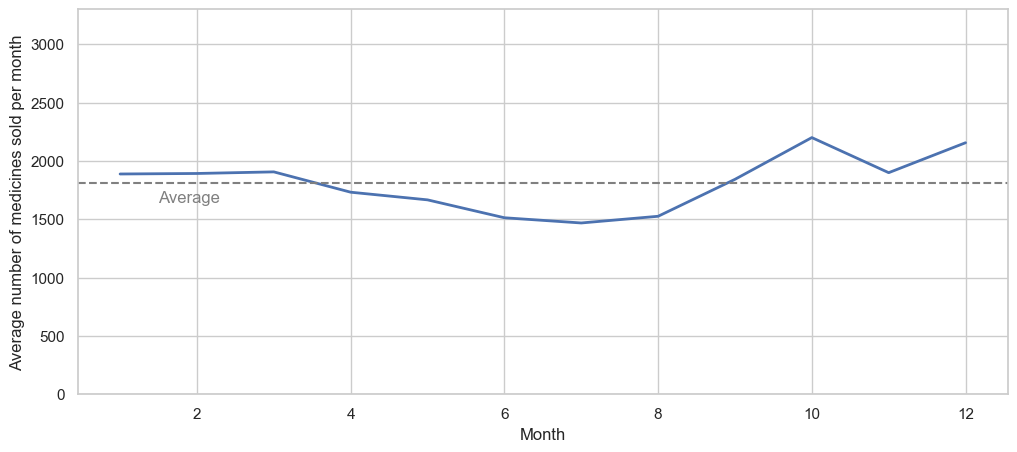

In [18]:
# General mean visualization
df2a = df2.sum(axis=1) # adding all of the sales of each medicine per month
df2a = pd.DataFrame(df2a)
df2a = df2a.rename(columns={0:'total'})

df2ax = sns.lineplot(x=df2a.index, y=df2a.total, lw=2)
df2ax.figure.set_size_inches(12,5)
df2ax.set(xlabel='Month', ylabel='Average number of medicines sold per month')
plt.ylim(0, df2a['total'].max()*1.5)
plt.axhline(df2a.total.mean(),xmin=0, xmax=1, color='grey', ls='--')
plt.text(0.12, 0.51, 'Average', horizontalalignment='center', verticalalignment='center',
        transform=df2ax.transAxes, color='grey')
plt.show()

In [19]:
# We can see that total sales are below the average sales during the period between april and september.
# They reach their highest volume in october.
# This visual shows that there's a seasonality in the sales of this products.
# This information should be taken into consideration when planning production, logistics and marketing actions.

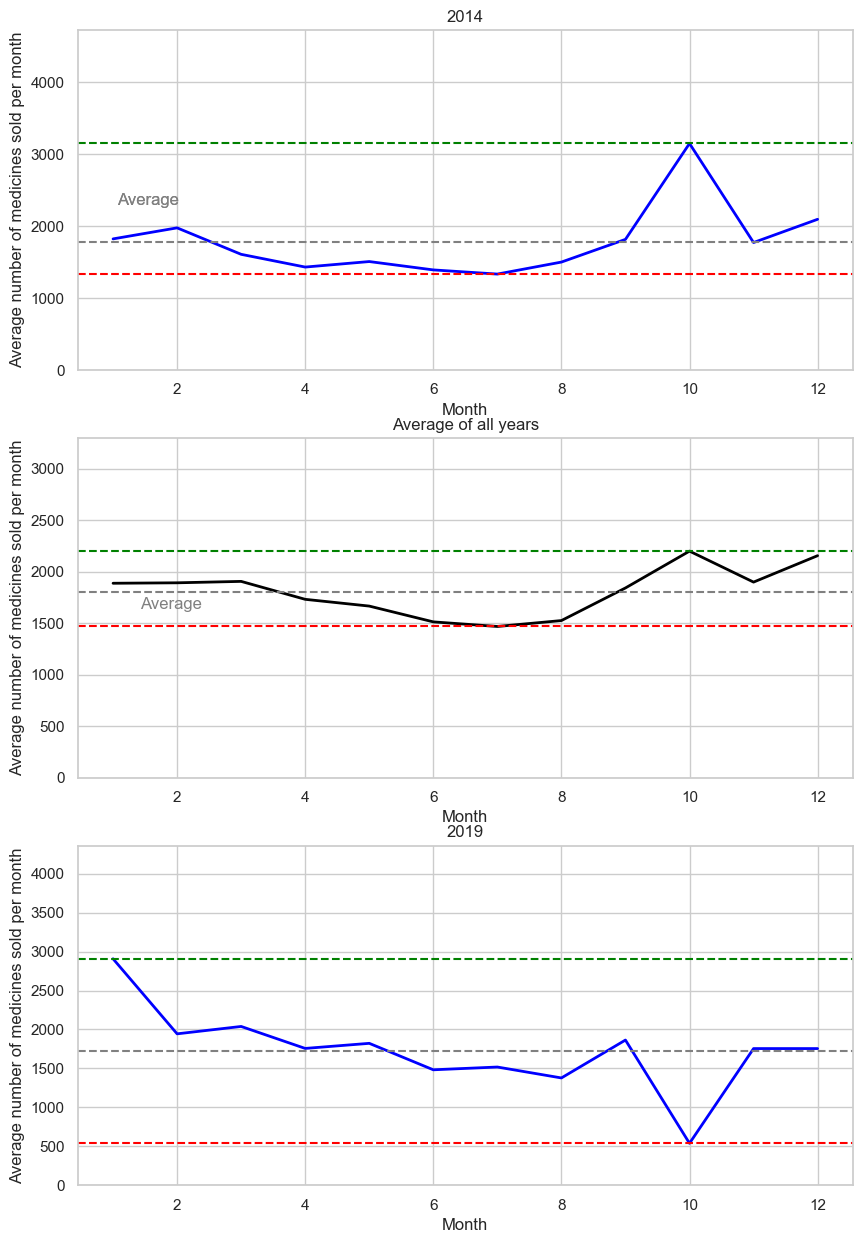

In [20]:
plt.figure(figsize=(10,15))

# Sales by month in 2014
df2014 = df2y.loc[df2y['year']==2014].drop('year',axis=1)
df2014 = df2014.set_index('month')
df2014 = df2014.sum(axis=1)

df2014 = pd.DataFrame(df2014)
df2014 = df2014.rename(columns={0:'total'})

# Sales by month in 2019
df2019 = df2y.loc[df2y['year']==2019].drop('year',axis=1)
df2019 = df2019.set_index('month')
df2019 = df2019.sum(axis=1)

df2019 = pd.DataFrame(df2019)
df2019 = df2019.rename(columns={0:'total'})

# Plotting the sum of the sales in the start and end year, compared to the mean across the years

# 2014 plot
plt.subplot(3,1,1)
df2014ax = sns.lineplot(x=df2014.index, y=df2014.total, color='blue', lw=2)
df2014ax.set(xlabel='Month', ylabel='Average number of medicines sold per month')
plt.ylim(0, df2014['total'].max()*1.5)
plt.axhline(df2014.total.mean(), xmin=0, xmax=1, color='grey', ls='--')
plt.axhline(df2014.total.max(), xmin=0, xmax=1, color='green', ls='--')
plt.axhline(df2014.total.min(), xmin=0, xmax=1, color='red', ls='--')

plt.text(0.09, 0.50, 'Average', horizontalalignment='center', verticalalignment='center', 
        transform=df2014ax.transAxes, color='grey')
plt.title('2014')

# Mean plot
plt.subplot(3,1,2)
df2ax = sns.lineplot(x=df2a.index, y=df2a.total, color='black', lw=2)
df2ax.set(xlabel='Month', ylabel='Average number of medicines sold per month')
plt.ylim(0, df2a['total'].max()*1.5)
plt.axhline(df2a.total.mean(),xmin=0, xmax=1, color='grey', ls='--')
plt.axhline(df2a.total.max(),xmin=0, xmax=1, color='green', ls='--')
plt.axhline(df2a.total.min(),xmin=0, xmax=1, color='red', ls='--')
plt.text(0.12, 0.51, 'Average', horizontalalignment='center', verticalalignment='center',
        transform=df2ax.transAxes, color='grey')
plt.title('Average of all years')

# 2019 plot
plt.subplot(3,1,3)
df2019ax = sns.lineplot(x=df2019.index, y=df2019.total, color='blue', lw=2)
df2019ax.set(xlabel='Month', ylabel='Average number of medicines sold per month')
plt.ylim(0, df2019['total'].max()*1.5)
plt.axhline(df2019.total.mean(), xmin=0, xmax=1, color='grey', ls='--')
plt.axhline(df2019.total.max(), xmin=0, xmax=1, color='green', ls='--')
plt.axhline(df2019.total.min(), xmin=0, xmax=1, color='red', ls='--')

plt.text(0.09, 0.50, 'Average', horizontalalignment='center', verticalalignment='center', 
        transform=df2014ax.transAxes, color='grey')
plt.title('2019')

plt.show()



In [21]:
# 2014 had a similar pattern to the average, where sales from april to september were below average and reaching peak sales in october.
# 2019 there was a completely different pattern. Year begin with sales above the average, but then fall sharply. Sales also remain below average between may and september.
# However october 2019 showed a neagtive peak in sales, the lowest of this year.

# What causes the sales to fall below average between april and august? What strategies could be implemented to improve this sales?
# What makes october generally the best month for sales? Is there something done around this month that can be applied at other times of the year?
# What factors were responsible for january and october being unusual when compared to the average overall behavior?

# Analyzing this factors could be useful for defining new business strategies and developing action plans to boost sales.


# Which medications are sold the most and the least each month?

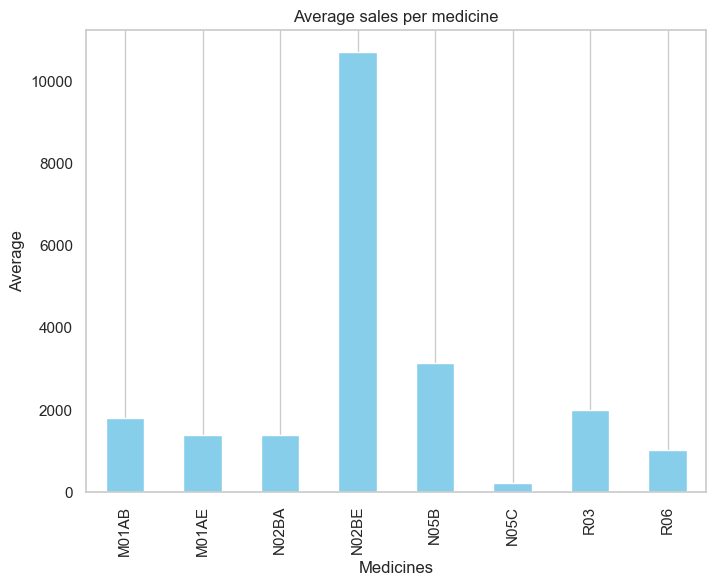

In [45]:
# Mean values bar chart
mean_values = df1.mean()
# print(mean_values.sort_values(ascending=False))

plt.figure(figsize=(8,6))
mean_values.plot(kind='bar', color='skyblue')
plt.xlabel('Medicines')
plt.ylabel('Average')
plt.title('Average sales per medicine')
plt.grid(axis='y')
plt.show()

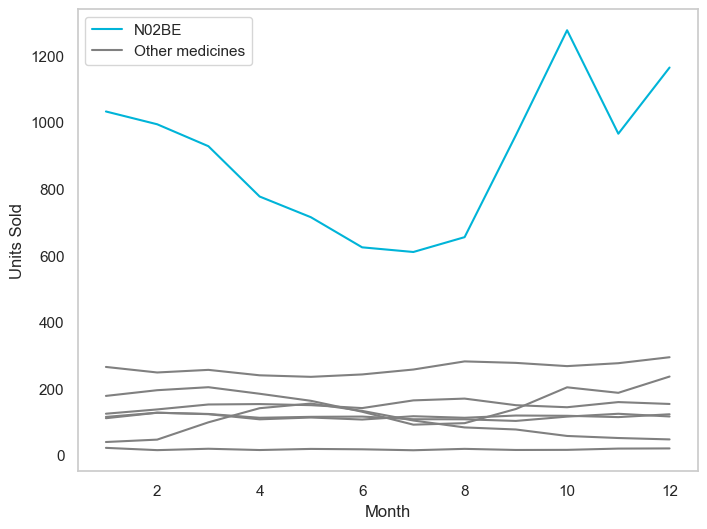

In [46]:
df2['total'] = df2.sum(axis=1)
fig, ax = plt.subplots(figsize=(8,6))

# Plotting the most sold medicines per month.
medicines = df2.columns[:-1].tolist()
color_lines = ['gray']*len(medicines)

# Finding the index of the most sold medicine (N02BE)
n02be_index = medicines.index('N02BE')
color_lines[n02be_index] = '#00B4D8' 

df2[medicines].plot(ax=ax, color=color_lines)
ax.grid(False)
ax.set_xlabel('Month')
ax.set_ylabel('Units Sold')

n02be_leyend = plt.Line2D([0], [0], color='#00B4D8', label='N02BE')
other_leyend = plt.Line2D([0], [0], color='grey', label='Other medicines')
ax.legend(handles=[n02be_leyend, other_leyend])

plt.show()



In [ ]:
# The best selling class of drug was analgesics and antipyretics (N02BE). The least sold class was N05C (psycholeptics, hypnotics, and sedatives).
# This may due to the fact that analgesics are commonly used and do not require prescription. 

In [50]:
# Let's analyze the monthly sales trends for most and least sold drugs.
df2yb = deepcopy(df2y)
df2yb = df2yb.loc[:, ['N02BE', 'N05C', 'month', 'year']]
df2yb = df2yb.loc[(df2yb.year==2014) | (df2yb.year==2019)] # Monthly sales for the years 2014 and 2019

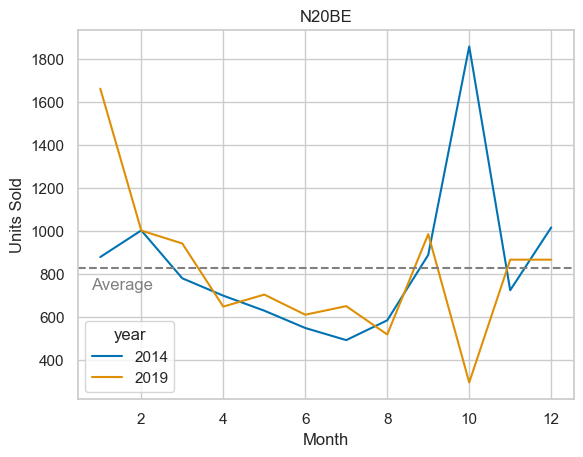

In [61]:
# Analyzing the most sold drug category as a function of the months
yx1 = sns.lineplot(x='month', y='N02BE', data=df2yb, hue='year', palette='colorblind')
yx1.set(xlabel='Month', ylabel='Units Sold')
plt.axhline(df2yb.N02BE.mean(), xmin=0, xmax=1, color='grey', ls='--')
plt.text(0.09, 0.31, 'Average', horizontalalignment='center',
         verticalalignment='center', transform=yx1.transAxes, color='grey')
plt.title('N20BE')
plt.show()

In [ ]:
# This medicine shows an increase in sales in January, but sales remain below average most of the year.
# There's a slight recovery during December
# Curiously, the sales above the average happen during the cold periods of the year

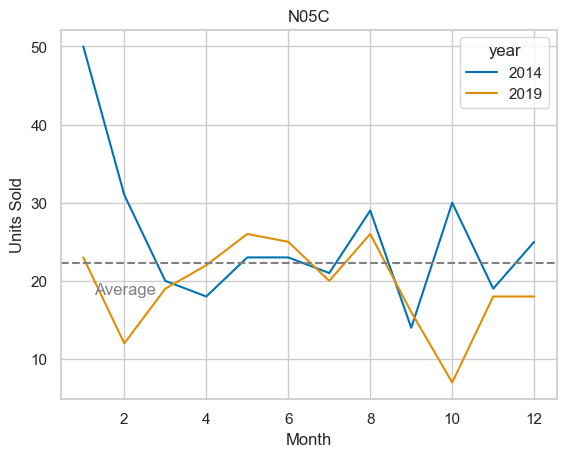

In [62]:
# Analyzing the least sold drug category as a function of the months
yx2 = sns.lineplot(x='month', y='N05C', data=df2yb, hue='year', palette='colorblind')
yx2.set(xlabel='Month', ylabel='Units Sold')
plt.axhline(df2yb.N05C.mean(), xmin=0, xmax=1, color='grey', ls='--')
plt.text(0.09, 0.31, 'Average', horizontalalignment='center',
         verticalalignment='center', transform=yx1.transAxes, color='grey')
plt.title('N05C')
plt.show()

In [ ]:
# For the least sold class of drug, there was no sudden change in the the sales from 2014 to 2019.
# Its observable that sales drop again during October.
# In contrast with N02BE, N05C sales seem to be higher during the period from april to july.

#  Is there a correlation between the monthly sales of certain classes of drugs?

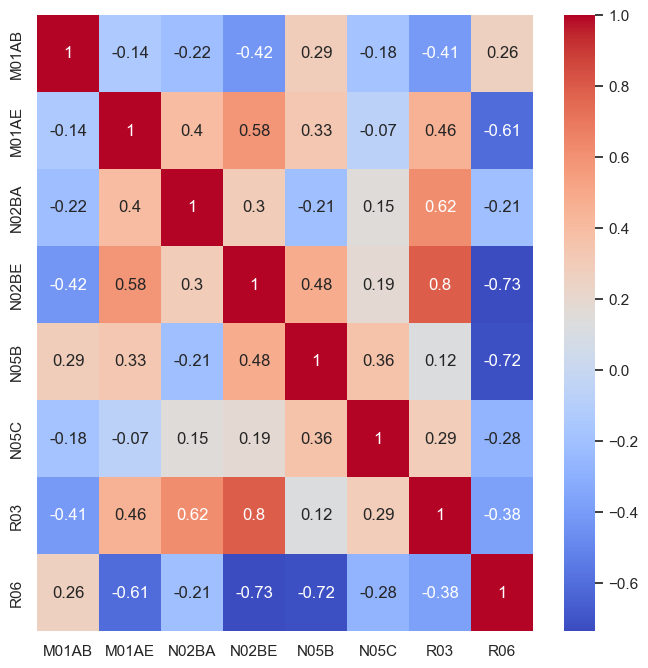

In [72]:
dfcorr = df2.drop(['total'], axis=1)
plt.figure(figsize=(8,8))
sns.heatmap(dfcorr.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Pearson correlation coefficient indicates strong positive or negative relations between our classes.
# We can observe that our class R06 has a strong negative correlation with classes N02BE and N05B.
# This indicates that the sales of these groups of medicines move in opposite directions.
# Whereas, medicines on class R03 have a strong positive correlation with medicines of the class N02BE.
# Sales of these groups move in similar directions. Which can suggest these groups usage dynamics are similar.

# Conclusions
    # Despite of the small observations of this data set, we were able to extract important insights such as:
        # Demand trends of each class of drug over the year and months, and changes in the dynamics of the sales as a function of the months.
        # Sales behavior of each specific class of medication over the months of the year.
        # Correlation between different classes of medication.
    # This data can assist in planning more in-depth analyses targeted at a specific objective
    # and can also serve as a starting point for creating predictive models that may be able to
    # predict sales of given drugs in the future.